## Notebook 3A — Regularisation & Model Selection

### 1. Loading Data and Initial Exploration

#### Importing libraries

In [76]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.metrics import (r2_score, mean_absolute_error, root_mean_squared_error)
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler)
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV)

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#### Importing synthetic data

In [2]:
df = pd.read_csv('Synthetic_Market_Dataframe.csv').drop('Unnamed: 0', axis = 1)

df.head()

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,ctr,cpc,impressions,revenue,total_spend,google_share,meta_share
0,19352.465824,12112.247848,7472.816369,7495.053656,3676.991724,0.016466,5.286084,85720,313151.792321,50109.575421,0.386203,0.241715
1,47585.001014,14466.351952,6658.241925,11201.201588,1004.108778,0.014253,3.944693,1726885,354471.126119,80914.905256,0.588087,0.178785
2,36867.703149,25709.148099,3523.078250,8440.001710,1798.534502,0.052293,7.733739,4013815,436025.243627,76338.465711,0.482951,0.336778
3,30334.265726,10530.129389,12145.333402,1249.538747,3350.075121,0.077628,2.142338,2142314,252781.463673,57609.342384,0.526551,0.182785
4,8644.913382,26154.665702,9532.483210,2783.703552,2462.237788,0.045190,4.908923,4004822,298776.377299,49578.003634,0.174370,0.527546


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   google_spend    5000 non-null   float64
 1   meta_spend      5000 non-null   float64
 2   tiktok_spend    5000 non-null   float64
 3   linkedin_spend  5000 non-null   float64
 4   email_spend     5000 non-null   float64
 5   ctr             5000 non-null   float64
 6   cpc             5000 non-null   float64
 7   impressions     5000 non-null   int64  
 8   revenue         5000 non-null   float64
 9   total_spend     5000 non-null   float64
 10  google_share    5000 non-null   float64
 11  meta_share      5000 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 468.9 KB


In [4]:
df.isnull().sum()

google_spend      0
meta_spend        0
tiktok_spend      0
linkedin_spend    0
email_spend       0
ctr               0
cpc               0
impressions       0
revenue           0
total_spend       0
google_share      0
meta_share        0
dtype: int64

In [5]:
df.nunique()

google_spend      5000
meta_spend        5000
tiktok_spend      5000
linkedin_spend    5000
email_spend       5000
ctr               5000
cpc               5000
impressions       5000
revenue           5000
total_spend       5000
google_share      5000
meta_share        5000
dtype: int64

In [6]:
df.describe()

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,ctr,cpc,impressions,revenue,total_spend,google_share,meta_share
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,25344.767559,14998.870169,10027.501070,7615.270498,2593.007861,0.044393,4.254607,2.512143e+06,325448.156958,60579.417156,0.396779,0.250853
std,14192.048904,8425.687025,5815.396355,4317.093267,1414.832211,0.019919,2.162441,1.430737e+06,70612.196321,18018.741849,0.173461,0.137207
min,1000.570103,501.558395,3.154892,3.786817,100.235807,0.010008,0.500042,1.175900e+04,94790.703480,9746.904138,0.017472,0.006983
25%,12949.277527,7790.804298,4943.346519,3940.939296,1368.589376,0.027300,2.356432,1.286755e+06,277657.886092,47204.818597,0.267347,0.147608
50%,25500.422653,14836.161434,9923.942667,7686.744586,2615.367868,0.044368,4.264259,2.506418e+06,328436.574863,60724.184819,0.421601,0.245865
75%,37656.942267,22134.462152,15212.380092,11266.583606,3812.713503,0.061251,6.111699,3.754201e+06,375647.414865,73834.257221,0.525111,0.338105
max,49986.165991,29985.403096,19996.102883,14998.872402,4999.514787,0.079981,7.998420,4.999780e+06,543448.282114,112790.680718,0.860357,0.826593


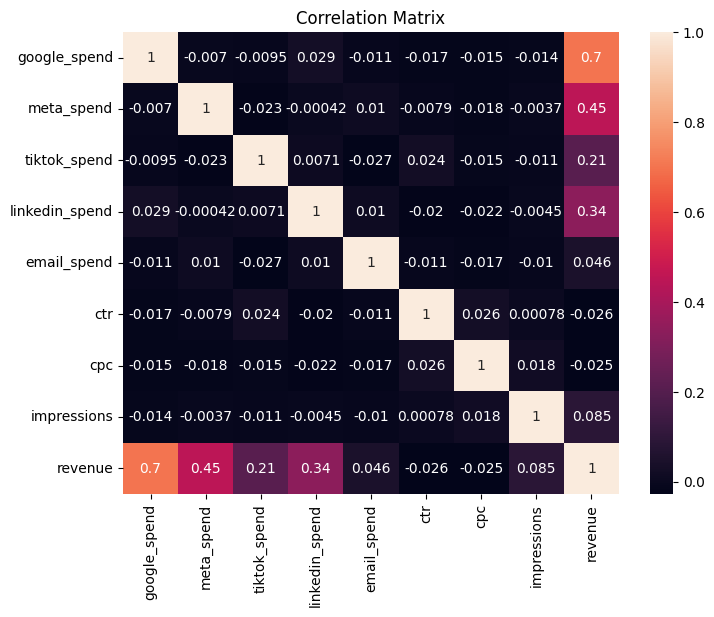

In [7]:
corr = df.drop(['total_spend', 'google_share', 'meta_share'], axis = 1).corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True)

plt.title('Correlation Matrix')
plt.show();

### 2. Feature Selection & Train/Test/Split

In [8]:
X = df.drop(['total_spend', 'revenue'], axis = 1)
# removing total_spend to prevent data leakage since it is the sum of individual channel spends

y = df['revenue']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'The shape of X_train{X_train.shape} matches the shape of y_train{y_train.shape}, likewise shape of X_test{X_test.shape} matches the shape of y_test{y_test.shape}.')

The shape of X_train(4000, 10) matches the shape of y_train(4000,), likewise shape of X_test(1000, 10) matches the shape of y_test(1000,).


### 3. Baseline Linear Regression Pipeline

In [13]:
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_pipe.fit(X_train, y_train)

linear_pred = linear_pipe.predict(X_test)

In [28]:
r2_linear = r2_score(y_test, linear_pred)

mae_linear = mean_absolute_error(y_test, linear_pred)

rmse_linear = root_mean_squared_error(y_test, linear_pred)

print(f'The R2_Score for Linear Regression comes to {r2_linear:.4f}.')
print(f'The Mean Absolute Error for Linear Regression comes to £{mae_linear:,.2f}.')
print(f'The Root Mean Squared Error for Linear Regression comes to £{rmse_linear:,.2f}.')

The R2_Score for Linear Regression comes to 0.8719.
The Mean Absolute Error for Linear Regression comes to £20,383.26.
The Root Mean Squared Error for Linear Regression comes to £25,666.95.


**Observation** 

Baseline Linear model is highly successful, explaining **87.19%** of the revenue variance with a true average error of **£25,666.95**.

### 4. Polynomial Regression Pipeline

In [10]:
results = []

for degreee in range(1,6):
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree = degreee, include_bias = False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    
    scores_cvs = cross_val_score(
        poly_pipe, X, y, cv = 5, scoring = 'r2'
    ).mean()

    results.append([degreee, scores_cvs])

results_df = pd.DataFrame(results, columns = ['Degree', 'R2_Score'])

print(results_df)

   Degree  R2_Score
0       1  0.867115
1       2  0.873207
2       3  0.865449
3       4  0.813058
4       5 -2.341795


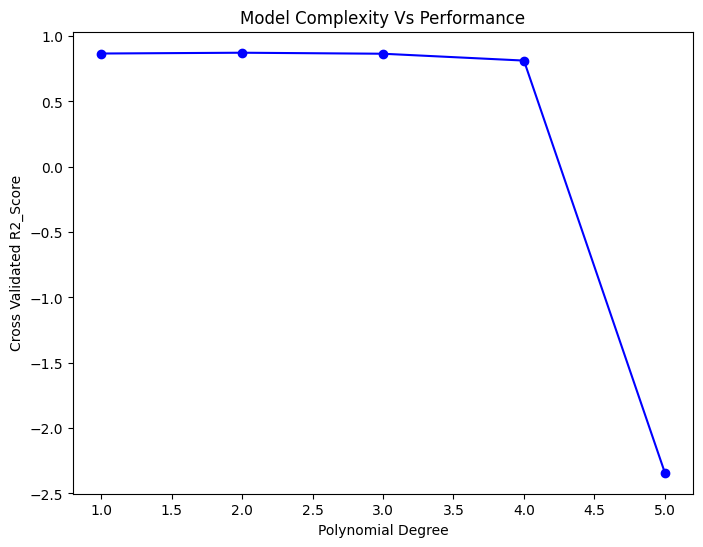

In [12]:
plt.figure(figsize = (8,6))
plt.plot(results_df['Degree'], results_df['R2_Score'], marker = 'o', color = 'blue')

plt.title('Model Complexity Vs Performance')
plt.xlabel('Polynomial Degree')
plt.ylabel('Cross Validated R2_Score')
plt.show();

**Observation**

Cross-validation showed that **Degree 2** gives a score of **0.8732**, which is a slight improvement over linear baseline **0.8719**.

However, Degree 2 created 77 features. Many of these interaction terms are highly correlated (multicollinearity) or completely useless.
Standard LinearRegression will try to use all 77 features, which can lead to overfitting or unstable weights.
Ridge/Lasso/Elastic Net act as filters. They look at those 77 features and suppress the useless or redundant interactions while keeping the ones that actually improved the score to 0.8732.

### 5.1 Solution - Ridge Regression

In Ridge Regression, **alpha** is the control dial for how harshly the model is punished for having massive, exploding coefficients.

In [31]:
ridge_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    # degree set as 2 for optimum performance
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha = 1.0))
    #  alpha is the control dial for how harshly the model for having massive, exploding coefficients.
])

ridge_pipe.fit(X_train, y_train)

ridge_pred = ridge_pipe.predict(X_test)

In [32]:
r2_ridge = r2_score(y_test, ridge_pred)

mae_ridge = mean_absolute_error(y_test, ridge_pred)

rmse_ridge = root_mean_squared_error(y_test, ridge_pred)

print(f'The R2_Score for Ridge Regression comes to {r2_ridge:.4f}.')
print(f'The Mean Absolute Error for Ridge Regression comes to £{mae_ridge:,.4f}.')
print(f'The Root Mean Squared Error for Ridge Regression comes to £{rmse_ridge:,.4f}.')

The R2_Score for Ridge Regression comes to 0.8773.
The Mean Absolute Error for Ridge Regression comes to £19,919.4102.
The Root Mean Squared Error for Ridge Regression comes to £25,114.7572.


### 5.2 Solution - Lasso Regression

In [40]:
lasso_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha = 1.0, max_iter = 100000))
    # Added max_iter to give it more steps
])

lasso_pipe.fit(X_train, y_train)

lasso_pred = lasso_pipe.predict(X_test)

In [41]:
r2_lasso = r2_score(y_test, lasso_pred)

mae_lasso = mean_absolute_error(y_test, lasso_pred)

rmse_lasso = root_mean_squared_error(y_test, lasso_pred)

print(f'The R2_Score for Lasso Regression comes to {r2_lasso:.4f}.')
print(f'The Mean Absolute Error for Lasso Regression comes to £{mae_lasso:,.4f}.')
print(f'The Root Mean Squared Error for Lasso Regression comes to £{rmse_lasso:,.4f}.')

The R2_Score for Lasso Regression comes to 0.8772.
The Mean Absolute Error for Lasso Regression comes to £19,939.5437.
The Root Mean Squared Error for Lasso Regression comes to £25,128.3935.


### 5.3 Solution - ElasticNet Regression

In [59]:
elastic_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha = 1.0, l1_ratio = 0.5))
    # 50/50 mix of Ridge & Lasso
])

elastic_pipe.fit(X_train, y_train)

elastic_pred = elastic_pipe.predict(X_test)

In [60]:
r2_elastic = r2_score(y_test, elastic_pred)

mae_elastic = mean_absolute_error(y_test, elastic_pred)

rmse_elastic = root_mean_squared_error(y_test, elastic_pred)

print(f'The R2_Score for ElasticNet Regression comes to {r2_elastic:.4f}.')
print(f'The Mean Absolute Error for ElasticNet Regression comes to £{mae_elastic:,.4f}.')
print(f'The Root Mean Squared Error for ElasticNet Regression comes to £{rmse_elastic:,.4f}.')

The R2_Score for ElasticNet Regression comes to 0.8586.
The Mean Absolute Error for ElasticNet Regression comes to £21,210.2845.
The Root Mean Squared Error for ElasticNet Regression comes to £26,966.0291.


#### Leaderboard Data when alpha = 1.0

In [75]:
leaderboard = {
    'Model_type': ['Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'R2_Score': [r2_linear, r2_ridge, r2_lasso, r2_elastic],
    'MAE (£)': [mae_linear, mae_ridge, mae_lasso, mae_elastic],
    'RMSE (£)': [rmse_linear, rmse_ridge, rmse_lasso, rmse_elastic]
}
leaderboard = pd.DataFrame(leaderboard).sort_values(by = 'R2_Score', ascending = False)

leaderboard.style.format({
    'R2_Score':'{:.4f}',
    'MAE (£)':'{:,.2f}',
    'RMSE (£)':'{:,.2f}'
})

,Model_type,R2_Score,MAE (£),RMSE (£)
1,Ridge,0.8773,"19,919.41","25,114.76"
2,Lasso,0.8772,"19,939.54","25,128.39"
0,Linear,0.8719,"20,383.26","25,666.95"
3,ElasticNet,0.8586,"21,210.28","26,966.03"


**Observation**

**Ridge Regression (alpha = 1.0)** is the definitive winner. It achieved the highest overall accuracy, crossed below the £20,000 average error barrier, and kept the outlier errors the lowest.

### 6. Automatic Hyperparameter Search

The primary benefit of using CV Model instead of a fixed alpha i.e. 1.0 is that it automatically finds the mathematically optimal regularizsation strength for a specific dataset, preventing underfitting or overfitting.

In previous Observation, Cross-validation showed that **Degree 2 gives a score of 0.8732**, which is a slight improvement over **linear baseline 0.8719**. Since the improvement is minor (+0.0013), removing the Polynomial Features from CV Pipelines offer three advantages:

**1. Speed & Memory Boost**

Without Polynomial Features (11 columns): Dataset remains strictly at its original 11 columns. Processing 11 columns across 50 different alphas takes less than a second.

With Polynomial Features (77 columns): Dataset expands drastically to 77 columns. Running cross-validation 50 distinct time across 77 features forces computer to calculate (50 * 5 = 250) matrix inversions, which will noticeably slow down code execution.

**2. Elimination of Multicollinearity**

The Benefit: Raw marketing spend columns (google_spend, meta_spend, etc.) represent clean, independent investments.

The Reality: The moment PolynomialFeatures are added, synthetic interaction terms (like google_spend * meta_share) are generated that are highly correlated with the raw inputs. Removing the polynomial step ensures model remains statistically stable and doesn't rely on heavily inflated coefficients.

**3. Clear, Actionable Business Insights (Interpretability)**

When the polynomial terms are removed, final model coefficients are incredibly easy for human stakeholders to understand. Instead of trying to interpret a complex interaction term like (google_spend * meta_share), a direct, clean answer like "_For every £1 scaled increase in Google Spend, revenue increases by exactly £X._" directly assists with budgeting and forecasting.

#### RidgeCV

In [95]:
ridgecv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas = np.logspace(-3,3,50)))
])

ridgecv_pipe.fit(X_train, y_train)

ridgecv_alpha = ridgecv_pipe.named_steps['model'].alpha_

print(f'The Optimal Ridge CV alpha for raw data is {ridgecv_alpha}.')

The Optimal Ridge CV alpha for raw data is 3.5564803062231287.


#### LassoCV

In [96]:
lassocv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas = np.logspace(-3,3,50)))
])

lassocv_pipe.fit(X_train, y_train)

lassocv_alpha = lassocv_pipe.named_steps['model'].alpha_

print(f'The Optimal LassoCV alpha for raw data is {lassocv_alpha}.')

The Optimal LassoCV alpha for raw data is 59.636233165946365.


#### ElasticNetCV

In [102]:
elasticcv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(alphas = np.logspace(-3,3,50)))
])

elasticcv_pipe.fit(X_train, y_train)

elasticcv_alpha = elasticcv_pipe.named_steps['model'].alpha_

print(f'The Optimal ElasticNetCV alpha for raw data is {elasticcv_alpha}.')

The Optimal ElasticNetCV alpha for raw data is 0.0017575106248547913.


In [112]:
opt_alpha = {
    'Model_type': ['RidgeCV', 'LassoCV', 'ElasticNetCV'],
    'Optimal_alpha': [ridgecv_alpha, lassocv_alpha, elasticcv_alpha]
}

pd.DataFrame(opt_alpha)

,Model_type,Optimal_alpha
0,RidgeCV,3.556480
1,LassoCV,59.636233
2,ElasticNetCV,0.001758


### 7. Linear Regression using Optimal alpha values

In [123]:
tuned_results = []

# Initialising the pipelines with exact optimal alphas
model_list = {
    'Ridge_raw': Ridge(alpha = ridgecv_alpha),
    'Lasso_raw': Lasso(alpha = lassocv_alpha),
    'ElasticNet_raw': ElasticNet(alpha = elasticcv_alpha, l1_ratio = 0.5)
}

# Looping through and evaluating each model WITHOUT PolynomialFeatures
for model_name, model_obj in model_list.items():
    model_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model_obj)
    ])

    # Fitting on raw training data
    model_pipe.fit(X_train, y_train)

    # Predicting on test data
    model_pred = model_pipe.predict(X_test)

    # Calculating Metrics
    r2_model = r2_score(y_test, model_pred)
    mae_model = mean_absolute_error(y_test, model_pred)
    rmse_model = root_mean_squared_error(y_test, model_pred)

    tuned_results.append([model_name, r2_model, mae_model, rmse_model])

df_tuned = pd.DataFrame(tuned_results, columns = ['Model_Type', 'R2_Score', 'MAE_Score (£)', 'RMSE_Score (£)'])

df_tuned.sort_values(by = ['R2_Score', 'MAE_Score (£)'], ascending = [False, True]).style.format({
    'R2_Score': '{:.4f}',
    'MAE_Score (£)':'{:,.2f}',
    'RMSE_Score (£)': '{:,.2f}'
})

,Model_Type,R2_Score,MAE_Score (£),RMSE_Score (£)
1,Lasso_raw,0.8720,"20,370.25","25,652.76"
0,Ridge_raw,0.8719,"20,379.50","25,660.94"
2,ElasticNet_raw,0.8719,"20,379.53","25,661.00"


**Key Takeaways**

With an (R^2) of approx. 0.8720, an MAE of £20,370.25, and an RMSE of £25,652.76, **Lasso marginally outperforms both Ridge and ElasticNet** across every single metric.

The Models are in Perfect Agreement because ElasticNet's optimal alpha was tuned to be incredibly tiny (0.0017), which essentially turned its penalty off, making it mathematically mirror Ridge.

**Validated Tradeoff**: Previous best Polynomial (Degree 2) Ridge model had an (R^2) of 0.8773. By choosing the simpler, cleaner Linear Lasso model, a tiny 0.53% in accuracy was sacrificed in exchange for a model that is 100% transparent, highly stable, and incredibly easy to explain to business stakeholders.

In [124]:
tuned_lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha = lassocv_alpha))
])

tuned_lasso_pipe.fit(X_train, y_train)

tuned_lasso_pred = tuned_lasso_pipe.predict(X_test)

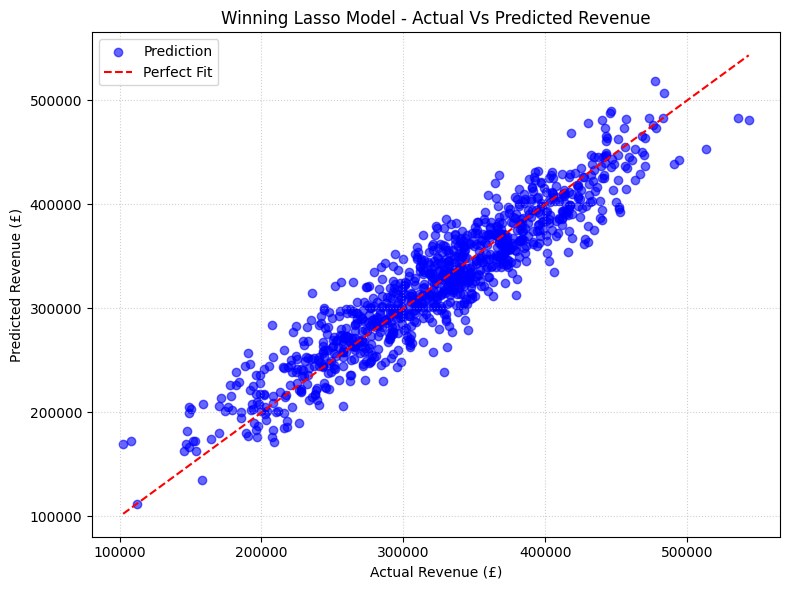

In [143]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, tuned_lasso_pred, color = 'blue', marker = 'o', alpha = 0.6, label = 'Prediction')

min_val = min(min(y_test), min(tuned_lasso_pred))
max_val = max(max(y_test), max(tuned_lasso_pred))

plt.plot([min_val, max_val], [min_val, max_val], color = 'red', linestyle = '--', label = 'Perfect Fit')

plt.title('Winning Lasso Model - Actual Vs Predicted Revenue')
plt.xlabel('Actual Revenue (£)')
plt.ylabel('Predicted Revenue (£)')
plt.legend()
plt.grid(True, linestyle = ':', alpha = 0.6)

plt.tight_layout()
plt.show();